## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.17 推論加速，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 21｜Transformer加速_推論與參數高效微調

量化 KV cache 的計算差異，並計算 LoRA 的可訓練參數量。

對應 `slides/21_Transformer加速_推論與參數高效微調.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/17_speeding_up_transformers.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Key/Value Caching、MQA／GQA、Faster Training 區段。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
lengths = np.array([16, 32, 64, 128, 256])
without_cache = lengths * (lengths + 1) / 2
with_cache = lengths
d_in = d_out = 4096; rank = 8
full = d_in * d_out
lora = rank * (d_in + d_out)
table = pd.DataFrame({'sequence_length': lengths,
                      'projected_token_states_without_cache': without_cache.astype(int),
                      'with_KV_cache': with_cache,
                      'ratio': without_cache / with_cache})
print(f'LoRA trainable parameters: {lora:,} vs full matrix {full:,} ({lora/full:.3%})')
table

LoRA trainable parameters: 65,536 vs full matrix 16,777,216 (0.391%)


,sequence_length,projected_token_states_without_cache,with_KV_cache,ratio
0,16,136,16,8.5
1,32,528,32,16.5
2,64,2080,64,32.5
3,128,8256,128,64.5
4,256,32896,256,128.5


## 執行結果圖

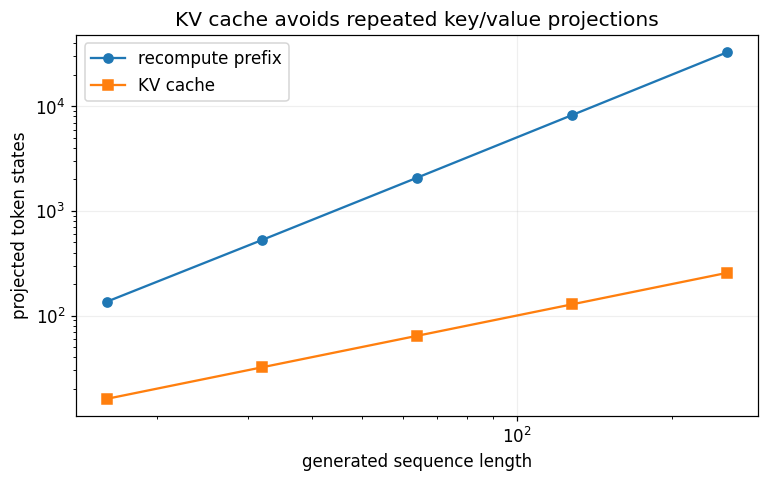

In [3]:
plt.loglog(lengths, without_cache, 'o-', label='recompute prefix')
plt.loglog(lengths, with_cache, 's-', label='KV cache')
plt.xlabel('generated sequence length'); plt.ylabel('projected token states')
plt.title('KV cache avoids repeated key/value projections'); plt.legend()
savefig('21_transformer_efficiency_demo')
report('transformer_efficiency', {'lora_params': lora, 'full_params': full, 'table': table.to_dict('records')})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。